#**Amerihome Data Project**

In [313]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/amerihome/
!ls

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/amerihome
'Data Project.xlsx'


In [314]:
#Load data and skip row 1 to avoid the unnessesary row
data = pd.read_excel('Data Project.xlsx', sheet_name="Data Project", skiprows=1)
fred = pd.read_excel('Data Project.xlsx', sheet_name="FRED Rate", skiprows=1)
data

,Date,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2024-10-08,4.96,4.85,4.75,4.44,4.21,3.98,3.86,3.86,3.94,4.04,4.38,4.32
1,2024-10-07,5.00,4.87,4.77,4.45,4.24,3.99,3.89,3.86,3.92,4.03,4.37,4.30
2,2024-10-04,5.01,4.88,4.73,4.45,4.20,3.93,3.84,3.81,3.88,3.98,4.33,4.26
3,2024-10-03,4.99,4.85,4.68,4.37,4.02,3.70,3.62,3.62,3.71,3.85,4.24,4.18
4,2024-10-02,4.92,4.83,4.69,4.36,3.97,3.63,3.54,3.55,3.65,3.79,4.19,4.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,2020-01-08,1.50,1.53,1.54,1.56,1.55,1.58,1.61,1.67,1.78,1.87,2.21,2.35
1191,2020-01-07,1.52,1.53,1.54,1.56,1.53,1.54,1.55,1.62,1.74,1.83,2.16,2.31
1192,2020-01-06,1.54,1.54,1.56,1.56,1.54,1.54,1.56,1.61,1.72,1.81,2.13,2.28
1193,2020-01-03,1.52,1.55,1.52,1.55,1.55,1.53,1.54,1.59,1.71,1.80,2.11,2.26


In [315]:
#pairplot for relationship between all bond and detect if there is a relationship between all yield
#plt.figure(figsize = (10,8))
#sns.pairplot(data)


In [316]:
fred

,DATE,OBMMIC30YF
0,2019-12-27,3.933
1,2019-12-30,3.952
2,2019-12-31,3.927
3,2020-01-01,.
4,2020-01-02,3.914
...,...,...
1242,2024-10-01,6.082
1243,2024-10-02,6.132
1244,2024-10-03,6.182
1245,2024-10-04,6.275


In [317]:
data.info()
fred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1195 non-null   datetime64[ns]
 1   1 Mo    1195 non-null   float64       
 2   2 Mo    1195 non-null   float64       
 3   3 Mo    1195 non-null   float64       
 4   6 Mo    1195 non-null   float64       
 5   1 Yr    1195 non-null   float64       
 6   2 Yr    1195 non-null   float64       
 7   3 Yr    1195 non-null   float64       
 8   5 Yr    1195 non-null   float64       
 9   7 Yr    1195 non-null   float64       
 10  10 Yr   1195 non-null   float64       
 11  20 Yr   1195 non-null   float64       
 12  30 Yr   1195 non-null   float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 121.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1247 entries, 0 to 1246
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      

In [318]:
data.isnull().sum()

,0
Date,0
1 Mo,0
2 Mo,0
3 Mo,0
6 Mo,0
1 Yr,0
2 Yr,0
3 Yr,0
5 Yr,0
7 Yr,0


In [319]:
fred.isnull().sum()

,0
DATE,0
OBMMIC30YF,0


In [320]:
non_numeric_count = fred['OBMMIC30YF'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"Number of non-numeric values before conversion: {non_numeric_count}")

Number of non-numeric values before conversion: 52


###As shown in the fred rate data there is a huge preprocessing and cleaning needed as the the column name is difference, the data type is not numeric in rate and also handling datetime in both data for later featrure engineering

In [321]:
#Preprocess the Fred Rate data
fred = fred.rename(columns={'DATE': 'Date'})
data['Date'] = pd.to_datetime(data['Date'])
fred['Date'] = pd.to_datetime(fred['Date'])

# Convert 'OBMMIC30YF' to numeric and convert non_numeric to NaN by coerce
fred['OBMMIC30YF'] = pd.to_numeric(fred['OBMMIC30YF'], errors='coerce')

# convert to float
fred['OBMMIC30YF'] = fred['OBMMIC30YF'].astype(float)

#fill null value in fred target by applying interpolating with linear and checking bidirectional
fred['OBMMIC30YF'] = fred['OBMMIC30YF'].interpolate(method='linear', limit_direction='both', limit=5)

# Drop rows with NaN values in 'OBMMIC30YF'
#fred = fred.dropna(subset=['OBMMIC30YF'])


##Next I visualize the Fred Rate to understand the performance of Fred rate and determine if there is any data need attention and how I can draw insight from treasury data to predict on this

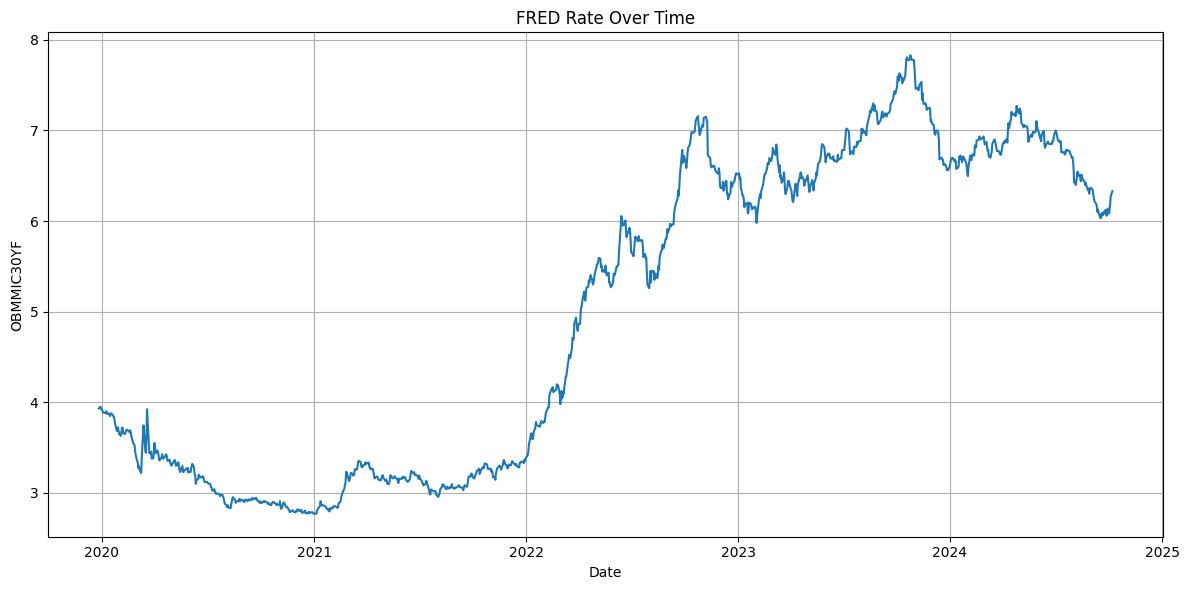

In [322]:
plt.figure(figsize=(12, 6))
plt.plot(fred['Date'], fred['OBMMIC30YF'])
plt.title('FRED Rate Over Time')
plt.xlabel('Date')
plt.ylabel('OBMMIC30YF')
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature Engineering

###This step I work on generate extra features on fred rate data, the reason for doing this is so that I can generate enough insight on rolling statistics, lag feature, difference, percentage, MA before merging so that I can gain more enough insight without handling unnessessary NaN value later

In [323]:
# Rolling mean and stdev
fred['OBM_roll3'] = fred['OBMMIC30YF'].rolling(3).mean()
fred['OBM_std3'] = fred['OBMMIC30YF'].rolling(3).std()
fred['OBM_roll5'] = fred['OBMMIC30YF'].rolling(5).mean()
fred['OBM_std5'] = fred['OBMMIC30YF'].rolling(5).std()
fred['OBM_roll7'] = fred['OBMMIC30YF'].rolling(7).mean()
fred['OBM_roll7'] = fred['OBMMIC30YF'].rolling(7).std()

# Differences and percent changes
fred['OBM_diff'] = fred['OBMMIC30YF'].diff()

# Exponential moving average
fred['OBM_ewm3'] = fred['OBMMIC30YF'].ewm(span=3, adjust=False).mean()
fred['OBM_ewm5'] = fred['OBMMIC30YF'].ewm(span=5, adjust=False).mean()
fred['OBM_ewm7'] = fred['OBMMIC30YF'].ewm(span=7, adjust=False).mean()

# Add lag features
fred['OBM_lag1'] = fred['OBMMIC30YF'].shift(1)
fred['OBM_lag3'] = fred['OBMMIC30YF'].shift(3)
fred['OBM_lag5'] = fred['OBMMIC30YF'].shift(5)
fred['OBM_lag7'] = fred['OBMMIC30YF'].shift(7)

# Drop NaNs
fred.dropna(inplace=True)

In [324]:
yield_cols = ['3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']

for col in yield_cols:
    data[f'{col}_diff'] = data[col].diff()
    data[f'{col}_lag1'] = data[col].shift(1)
    data[f'{col}_lag3'] = data[col].shift(3)
    data[f'{col}_lag5'] = data[col].shift(5)
    data[f'{col}_lag7'] = data[col].shift(7)

data.dropna(inplace=True)

#Preprocessing step 2: Merging and generate insight from merged data


In [325]:
#use inner merge to make sure there is data on both side to avoid on data manipulation that can skew the model learning process

merged_data = pd.merge(data, fred, on='Date', how='inner')
merged_data

,Date,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,...,OBM_std5,OBM_roll7,OBM_diff,OBM_ewm3,OBM_ewm5,OBM_ewm7,OBM_lag1,OBM_lag3,OBM_lag5,OBM_lag7
0,2024-09-27,4.90,4.87,4.68,4.35,3.90,3.55,3.49,3.50,3.60,...,0.027835,0.026152,-0.068,6.083474,6.087601,6.090921,6.127,6.113,6.0620,6.0830
1,2024-09-26,4.90,4.87,4.68,4.38,3.96,3.60,3.54,3.55,3.65,...,0.026837,0.022689,0.050,6.107948,6.101901,6.101562,6.077,6.107,6.0880,6.0310
2,2024-09-25,4.79,4.78,4.69,4.36,3.89,3.53,3.49,3.52,3.65,...,0.021055,0.027763,-0.036,6.088896,6.089352,6.093082,6.113,6.062,6.0830,6.0380
3,2024-09-24,4.78,4.78,4.69,4.36,3.88,3.49,3.44,3.47,3.60,...,0.020330,0.032077,0.006,6.100792,6.095528,6.098443,6.107,6.088,6.0310,6.0960
4,2024-09-23,4.85,4.84,4.72,4.40,3.91,3.57,3.47,3.51,3.62,...,0.028978,0.029197,0.045,6.088585,6.086792,6.093590,6.062,6.083,6.0380,6.1300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,2020-01-13,1.54,1.56,1.57,1.57,1.53,1.58,1.60,1.65,1.76,...,0.011459,0.009572,0.006,3.881733,3.885665,3.889757,3.873,3.892,3.8820,3.9140
1181,2020-01-10,1.52,1.55,1.54,1.55,1.53,1.56,1.59,1.63,1.74,...,0.011100,0.013782,-0.029,3.884466,3.888997,3.893342,3.902,3.882,3.8890,3.9205
1182,2020-01-09,1.53,1.55,1.54,1.56,1.54,1.58,1.59,1.65,1.77,...,0.008295,0.015299,0.010,3.895932,3.896996,3.900123,3.892,3.882,3.9140,3.9270
1183,2020-01-08,1.50,1.53,1.54,1.56,1.55,1.58,1.61,1.67,1.78,...,0.013161,0.019027,0.010,3.889863,3.894494,3.899498,3.882,3.889,3.9205,3.9520


###Next I will work on mostly the treasury data where I can calculate all the relationship of yield curve Slops, Interaction between bonds yeild and generate date feature from date data

In [326]:
yield_cols = ['3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']

# Yield Curve Slopes
from itertools import combinations

for short, long in combinations(yield_cols, 2):
    slope_name = f"{short}_{long}_slope"
    merged_data[slope_name] = merged_data[long] - merged_data[short]
    merged_data[f"{slope_name}_diff"] = merged_data[slope_name].diff()


# Date-Based Features
merged_data['DayOfWeek'] = merged_data['Date'].dt.dayofweek
merged_data['Month'] = merged_data['Date'].dt.month
merged_data['Quarter'] = merged_data['Date'].dt.quarter


In [327]:
#Data after engineering
merged_data

,Date,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,...,7 Yr_30 Yr_slope_diff,10 Yr_20 Yr_slope,10 Yr_20 Yr_slope_diff,10 Yr_30 Yr_slope,10 Yr_30 Yr_slope_diff,20 Yr_30 Yr_slope,20 Yr_30 Yr_slope_diff,DayOfWeek,Month,Quarter
0,2024-09-27,4.90,4.87,4.68,4.35,3.90,3.55,3.49,3.50,3.60,...,NaN,0.40,NaN,0.35,NaN,-0.05,NaN,4,9,3
1,2024-09-26,4.90,4.87,4.68,4.38,3.96,3.60,3.54,3.55,3.65,...,-0.03,0.38,-0.02,0.33,-2.000000e-02,-0.05,8.881784e-16,3,9,3
2,2024-09-25,4.79,4.78,4.69,4.36,3.89,3.53,3.49,3.52,3.65,...,0.02,0.39,0.01,0.35,2.000000e-02,-0.04,1.000000e-02,2,9,3
3,2024-09-24,4.78,4.78,4.69,4.36,3.88,3.49,3.44,3.47,3.60,...,0.00,0.39,0.00,0.35,0.000000e+00,-0.04,0.000000e+00,1,9,3
4,2024-09-23,4.85,4.84,4.72,4.40,3.91,3.57,3.47,3.51,3.62,...,-0.02,0.37,-0.02,0.34,-1.000000e-02,-0.03,1.000000e-02,0,9,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,2020-01-13,1.54,1.56,1.57,1.57,1.53,1.58,1.60,1.65,1.76,...,0.01,0.31,0.01,0.45,-2.220446e-16,0.14,-1.000000e-02,0,1,1
1181,2020-01-10,1.52,1.55,1.54,1.55,1.53,1.56,1.59,1.63,1.74,...,0.00,0.31,0.00,0.45,0.000000e+00,0.14,0.000000e+00,4,1,1
1182,2020-01-09,1.53,1.55,1.54,1.56,1.54,1.58,1.59,1.65,1.77,...,0.07,0.32,0.01,0.53,8.000000e-02,0.21,7.000000e-02,3,1,1
1183,2020-01-08,1.50,1.53,1.54,1.56,1.55,1.58,1.61,1.67,1.78,...,-0.04,0.34,0.02,0.48,-5.000000e-02,0.14,-7.000000e-02,2,1,1


In [328]:
merged_data = merged_data.dropna()

In [329]:
merged_data.replace([np.inf, -np.inf], 0, inplace=True)


<ipython-input-329-0a124982b3e7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data.replace([np.inf, -np.inf], 0, inplace=True)


#**Predictive Modeling Step 2 Method**

##ACF and PACF plotting



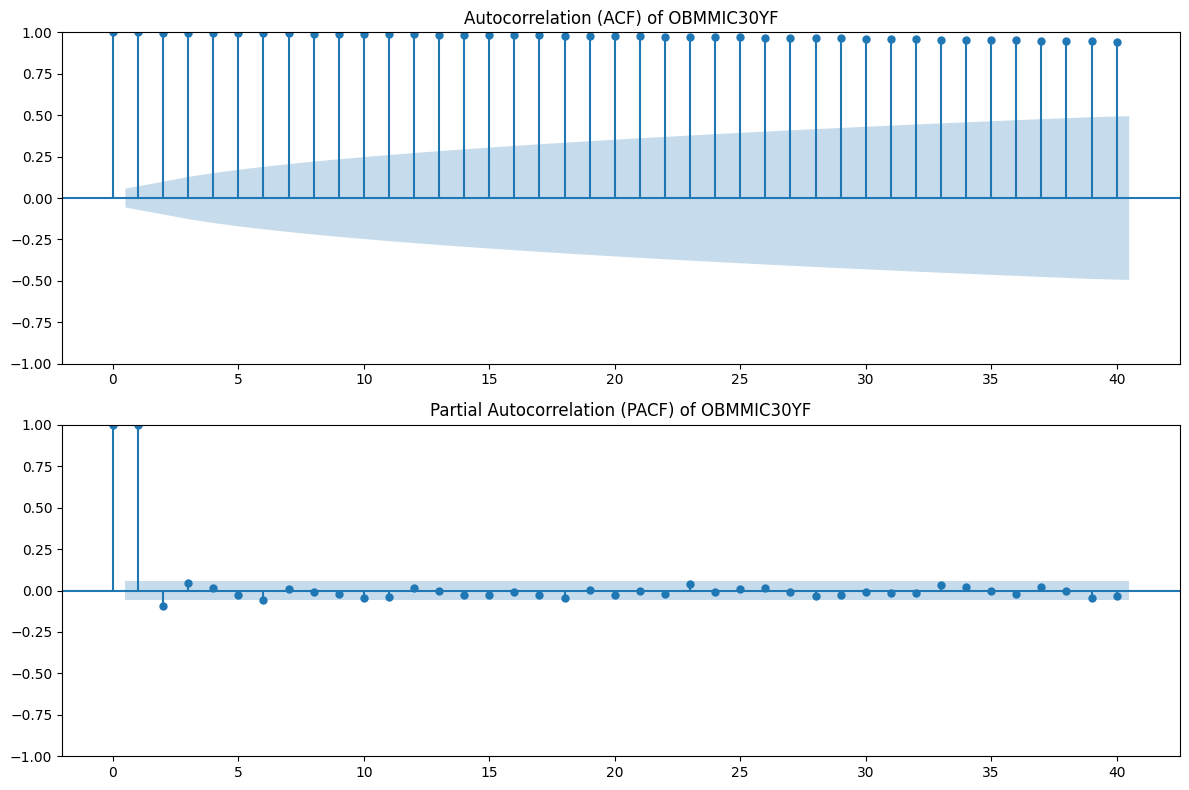

In [330]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

target_series = merged_data[['Date', 'OBMMIC30YF']].dropna().sort_values('Date')
y = target_series['OBMMIC30YF']

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y, lags=40, ax=ax[0])
ax[0].set_title("Autocorrelation (ACF) of OBMMIC30YF")

plot_pacf(y, lags=40, ax=ax[1], method='ywm')
ax[1].set_title("Partial Autocorrelation (PACF) of OBMMIC30YF")

plt.tight_layout()
plt.show()

###From the ACF and PACF graph I can see that there is slow decay after 40 days and show a slightly non-stationary therefore d = 1. For PACF there is drop at lag2 therefore p =2 at AR(2). For MA component there is slight sign which in this case I will take into consider at MA(1) model so q=1

##Before working on the modeling process I want to work on to reduce dimensionality since the ratio of features/length is too high and this will take in bias and overfitting, therefore applying PCA to remove collinearity and reduce dimensionality for model simplification

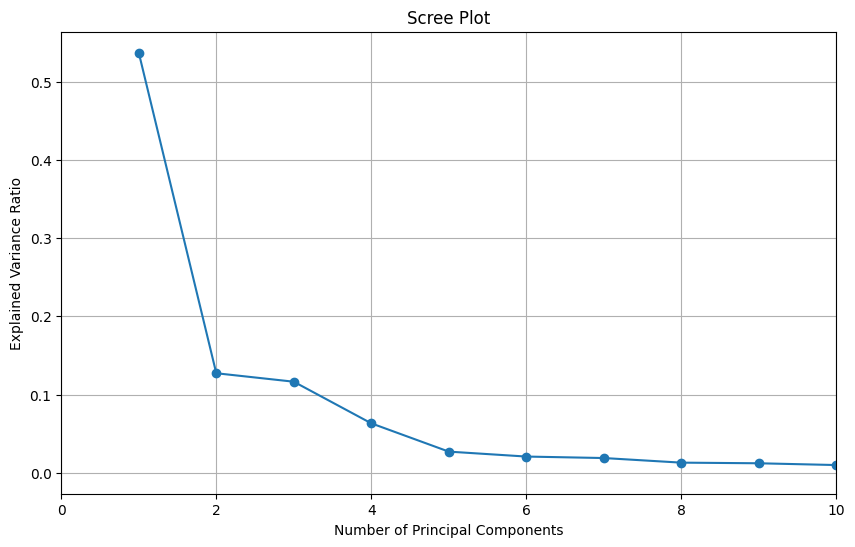

In [331]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = merged_data.drop(['OBMMIC30YF', 'Date'], axis=1)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xlim(0, 10)
plt.show()

## Linear Regression with 5PC

In [332]:
n_components = 2

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)


In [333]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca = sm.add_constant(X_pca)

model = sm.OLS(np.log1p(y), X_pca)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             OBMMIC30YF   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 1.550e+04
Date:                Thu, 24 Apr 2025   Prob (F-statistic):               0.00
Time:                        23:28:26   Log-Likelihood:                 1706.8
No. Observations:                1184   AIC:                            -3408.
Df Residuals:                    1181   BIC:                            -3392.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7466      0.002   1048.621      0.0

In [339]:
#remove pc2
keep_cols = [0, 1]

X_selected = X_pca[:, keep_cols]

model = sm.OLS(np.log1p(y), X_selected)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             OBMMIC30YF   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 3.100e+04
Date:                Thu, 24 Apr 2025   Prob (F-statistic):               0.00
Time:                        23:30:00   Log-Likelihood:                 1706.2
No. Observations:                1184   AIC:                            -3408.
Df Residuals:                    1182   BIC:                            -3398.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7466      0.002   1048.520      0.0

###This conclude our LR model with all feature is a good fit with significant level of 0.05 with low AIC, BIC number and good log likelihood, however there is a low durbin-watson, which I will proceed to work on the SARIMAX for better autocorrelation


## Model2: SARIMAX with 5PC

### For next I will work on applying the SARIMAX model in this case with tuning and comparison whether it is a better application than LR model

In [340]:
sarimax_pca = SARIMAX(np.log1p(y_train_pca), exog=X_train_pca, order=(2, 1, 1),
                      enforce_stationarity=False, enforce_invertibility=False)
sarimax_pca_fit = sarimax_pca.fit(disp=False)

y_pred_sarimax_pca = sarimax_pca_fit.forecast(steps=len(y_test_pca), exog=X_test_pca)

rmse_sarimax_pca = mean_squared_error(y_test_pca, y_pred_sarimax_pca)**0.5
r2_sarimax_pca = r2_score(y_test_pca, y_pred_sarimax_pca)

print(sarimax_pca_fit.summary())

print(f"SARIMAX with PCA - RMSE: {rmse_sarimax_pca:.4f}")
print(f"SARIMAX with PCA - R-squared: {r2_sarimax_pca:.4f}")

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             OBMMIC30YF   No. Observations:                  828
Model:               SARIMAX(2, 1, 1)   Log Likelihood                1984.401
Date:                Thu, 24 Apr 2025   AIC                          -3954.801
Time:                        23:30:12   BIC                          -3921.794
Sample:                             0   HQIC                         -3942.140
                                - 828                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.567e-10    1.5e-08     -0.010      0.992   -2.96e-08    2.93e-08
x1            -0.0114   8.48e-05   -134.573      0.000      -0.012      -0.011
x2         -1.571e-05      0.000     -0.089      0.9

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### This indicate a decent fit with high likelihood and low AIC/BIC, however there is a poor performance within the model given unsignificant pc2, pc4, pc5 pc with all the time series term. I will work on removing MA step or other feature if needed

In [341]:
keep_cols = [0, 1, 2]

X_selected = X_pca[:, keep_cols]
y = merged_data["OBMMIC30YF"]

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_selected, np.log1p(y), test_size=0.3, random_state=42)

model = SARIMAX(y_train,
                exog=X_train_pca,
                order=(0, 1, 1),
                enforce_stationarity=False,
                enforce_invertibility=False)
fit = model.fit(disp=False, cov_type='robust')
print(fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             OBMMIC30YF   No. Observations:                  828
Model:               SARIMAX(0, 1, 1)   Log Likelihood                1128.943
Date:                Thu, 24 Apr 2025   AIC                          -2247.887
Time:                        23:30:18   BIC                          -2224.310
Sample:                             0   HQIC                         -2238.843
                                - 828                                         
Covariance Type:               robust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.304e-11          0       -inf      0.000    -3.3e-11    -3.3e-11
x1             0.0308      0.000    177.745      0.000       0.030       0.031
x2             0.0023      0.000      4.640      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


### yield a strong result with significant Ljung-Box stat along with high log likelihood, however with log JB score, this require backtesting with GARCH


In [342]:
!pip install arch
from arch import arch_model

In [343]:
resid = fit.resid.dropna()

garch_model = arch_model(resid, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                1115.65
Distribution:                  Normal   AIC:                          -2223.30
Method:            Maximum Likelihood   BIC:                          -2204.43
                                        No. Observations:                  828
Date:                Thu, Apr 24 2025   Df Residuals:                      827
Time:                        23:30:31   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.2977e-03  2.454e-03     -0.529      0.

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008262. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


### garch is not needed in this case. I can keep (0,1,1) model for forecasting

###In this case I successfully predict accurately based on clean data, and decide to apply to prediction for faster run time and easier to work on tuning process and can be taken further for Boosting method. However I still need to check on the performance on unseen data, therefore in this case I apply 3 method of testing.